# Conn2Conn — CovType Results

Thin runner notebook for CovProjector covariate-type experiments.
All scraping/grouping logic lives in `results/results_scraper.py`.


In [9]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from results.results_scraper import (
    WANDB_ENTITY,
    WANDB_PROJECT,
    build_experiment_records_covtype,
    build_covtype_status_table,
    build_covtype_metric_table,
    records_to_df,
    enrich_records_with_local,
)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)


## 1. Experiment Spec


In [10]:
MODEL = "CrossModal_PCA_PLS_CovProjector"
SOURCES = ["SC"]
SEEDS = [0, 1, 2, 3, 4]
COV_TYPES = ["fs_all", "fs_volumes", "demo", "fs_all_demo"]

METRICS_OF_INTEREST = [
    "demeaned_pearson",
    "pearson",
    "mse",
    "avg_rank",
    "top1_acc",
]


## 2. Fetch Records (CovType-Aware)


In [11]:
records = build_experiment_records_covtype(
    models=[MODEL],
    sources=SOURCES,
    seeds=SEEDS,
    cov_types=COV_TYPES,
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    count_trials=True,
    verbose=True,
)
print(f"Expected matrix size: {len([MODEL]) * len(SOURCES) * len(COV_TYPES) * len(SEEDS)}")
print(f"Returned records: {len(records)}")


Fetching W&B runs for CrossModal_PCA_PLS_CovProjector…
  ✓ CrossModal_PCA_PLS_CovProjector | src=SC | cov=demo | seed=4 → 24 tune trials  (run: 884c24d7_best)
  ✓ CrossModal_PCA_PLS_CovProjector | src=SC | cov=fs_all_demo | seed=4 → 24 tune trials  (run: 6ed5c7ae_best)
  ✓ CrossModal_PCA_PLS_CovProjector | src=SC | cov=fs_all | seed=4 → 24 tune trials  (run: 6f63bce0_best)
  ✓ CrossModal_PCA_PLS_CovProjector | src=SC | cov=fs_volumes | seed=4 → 24 tune trials  (run: 61302b9d_best)
  ✓ CrossModal_PCA_PLS_CovProjector | src=SC | cov=fs_all_demo | seed=3 → 24 tune trials  (run: 7044ef7e_best)
  ✓ CrossModal_PCA_PLS_CovProjector | src=SC | cov=fs_all | seed=3 → 24 tune trials  (run: bd63da4f_best)
  ✓ CrossModal_PCA_PLS_CovProjector | src=SC | cov=fs_all_demo | seed=2 → 24 tune trials  (run: 47ca0457_best)
  ✓ CrossModal_PCA_PLS_CovProjector | src=SC | cov=fs_volumes | seed=2 → 24 tune trials  (run: 97ef1525_best)
  ✓ CrossModal_PCA_PLS_CovProjector | src=SC | cov=demo | seed=3 → 24 tune t

## 3. Status Table


In [12]:
status = build_covtype_status_table(records)
display(status)


cov_type                                demo                         fs_all                         fs_all_demo                         fs_volumes        \
seed                                       0     1     2     3     4      0     1     2     3     4           0     1     2     3     4          0     1   
model                           source                                                                                                                     
CrossModal_PCA_PLS_CovProjector SC      ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24   ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24        ✓ 24  ✓ 24  ✓ 24  ✓ 24  ✓ 24       ✓ 24  ✓ 24   

cov_type                                                  
seed                                       2     3     4  
model                           source                    
CrossModal_PCA_PLS_CovProjector SC      ✓ 24  ✓ 24  ✓ 24

## 4. Core Metric Tables (Mean ± Std Across Seeds)


In [17]:
for metric in METRICS_OF_INTEREST:
    table = build_covtype_metric_table(
        records,
        metric=metric,
        agg="mean±std",
        cov_types=COV_TYPES,
    )
    print(f"Test {metric} by cov_type — mean ± std across seeds")
    display(table)


Test demeaned_pearson by cov_type — mean ± std across seeds


,cov_type,fs_all,fs_volumes,demo,fs_all_demo
model,source,,,,
CrossModal_PCA_PLS_CovProjector,SC,0.0889 ± 0.0152 (n=5),0.0888 ± 0.0108 (n=5),0.1007 ± 0.0130 (n=5),0.0982 ± 0.0110 (n=5)


Test pearson by cov_type — mean ± std across seeds


,cov_type,fs_all,fs_volumes,demo,fs_all_demo
model,source,,,,
CrossModal_PCA_PLS_CovProjector,SC,0.8337 ± 0.0043 (n=5),0.8340 ± 0.0040 (n=5),0.8349 ± 0.0041 (n=5),0.8338 ± 0.0043 (n=5)


Test mse by cov_type — mean ± std across seeds


,cov_type,fs_all,fs_volumes,demo,fs_all_demo
model,source,,,,
CrossModal_PCA_PLS_CovProjector,SC,0.0137 ± 0.0002 (n=5),0.0137 ± 0.0002 (n=5),0.0136 ± 0.0002 (n=5),0.0137 ± 0.0002 (n=5)


Test avg_rank by cov_type — mean ± std across seeds


,cov_type,fs_all,fs_volumes,demo,fs_all_demo
model,source,,,,
CrossModal_PCA_PLS_CovProjector,SC,0.6991 ± 0.0346 (n=5),0.7191 ± 0.0269 (n=5),0.7316 ± 0.0290 (n=5),0.7163 ± 0.0297 (n=5)


Test top1_acc by cov_type — mean ± std across seeds


,cov_type,fs_all,fs_volumes,demo,fs_all_demo
model,source,,,,
CrossModal_PCA_PLS_CovProjector,SC,0.0431 ± 0.0151 (n=5),0.0390 ± 0.0209 (n=5),0.0431 ± 0.0154 (n=5),0.0492 ± 0.0147 (n=5)


## 5. Numeric Mean / Std Tables


In [18]:
for metric in METRICS_OF_INTEREST:
    mean_table = build_covtype_metric_table(records, metric=metric, agg="mean", cov_types=COV_TYPES)
    std_table = build_covtype_metric_table(records, metric=metric, agg="std", cov_types=COV_TYPES)

    print(f"Test {metric} — mean")
    display(mean_table)

    print(f"Test {metric} — std")
    display(std_table)


Test demeaned_pearson — mean


,cov_type,fs_all,fs_volumes,demo,fs_all_demo
model,source,,,,
CrossModal_PCA_PLS_CovProjector,SC,0.08886,0.088809,0.100713,0.098188


Test demeaned_pearson — std


,cov_type,fs_all,fs_volumes,demo,fs_all_demo
model,source,,,,
CrossModal_PCA_PLS_CovProjector,SC,0.016994,0.012112,0.014568,0.012316


Test pearson — mean


...

,cov_type,fs_all,fs_volumes,demo,fs_all_demo
model,source,,,,
CrossModal_PCA_PLS_CovProjector,SC,0.038715,0.030068,0.032411,0.033179


Test top1_acc — mean


,cov_type,fs_all,fs_volumes,demo,fs_all_demo
model,source,,,,
CrossModal_PCA_PLS_CovProjector,SC,0.043077,0.038974,0.043077,0.049231


Test top1_acc — std


,cov_type,fs_all,fs_volumes,demo,fs_all_demo
model,source,,,,
CrossModal_PCA_PLS_CovProjector,SC,0.016853,0.023388,0.017239,0.016458


## 6. Per-Seed Data + Plots


,model,source,cov_type,seed,test_demeaned_pearson,test_pearson,test_mse,test_avg_rank,test_top1_acc
0,CrossModal_PCA_PLS_CovProjector,SC,fs_all,0,0.079406,0.837252,0.013473,0.654832,0.046154
1,CrossModal_PCA_PLS_CovProjector,SC,fs_all,1,0.107567,0.828269,0.013969,0.720736,0.046154
2,CrossModal_PCA_PLS_CovProjector,SC,fs_all,2,0.068361,0.834026,0.013848,0.663458,0.020513
3,CrossModal_PCA_PLS_CovProjector,SC,fs_all,3,0.083701,0.829617,0.013755,0.710664,0.066667
4,CrossModal_PCA_PLS_CovProjector,SC,fs_all,4,0.105262,0.839371,0.013674,0.745615,0.035897
5,CrossModal_PCA_PLS_CovProjector,SC,fs_volumes,0,0.074838,0.839068,0.013340,0.683945,0.010256
6,CrossModal_PCA_PLS_CovProjector,SC,fs_volumes,1,0.098810,0.828423,0.013951,0.748271,0.041026
7,CrossModal_PCA_PLS_CovProjector,SC,fs_volumes,2,0.083481,0.835534,0.013724,0.698856,0.020513
8,CrossModal_PCA_PLS_CovProjector,SC,fs_volumes,3,0.082970,0.830468,0.013697,0.712610,0.061538
9,CrossModal_PCA_PLS_CovProjector,SC,fs_volumes,4,0.103945,0.836731,0.013858,0.751926,0.061538


/tmp/ipykernel_3992207/3021143898.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, patch_artist=True)


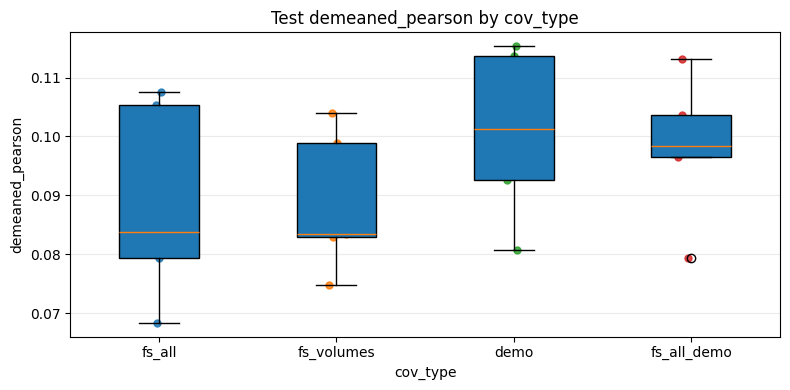

/tmp/ipykernel_3992207/3021143898.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, patch_artist=True)


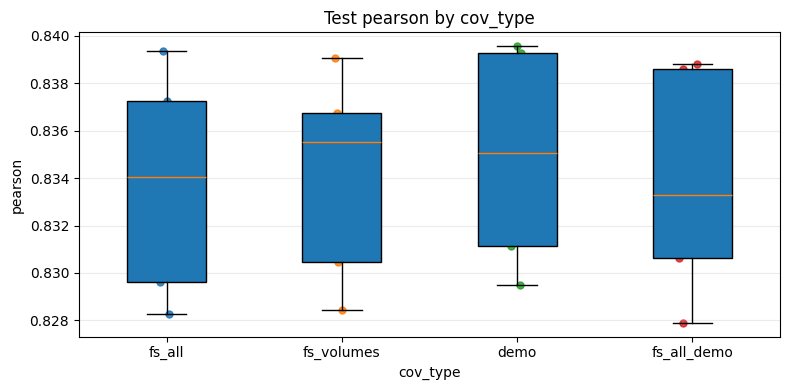

/tmp/ipykernel_3992207/3021143898.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, patch_artist=True)


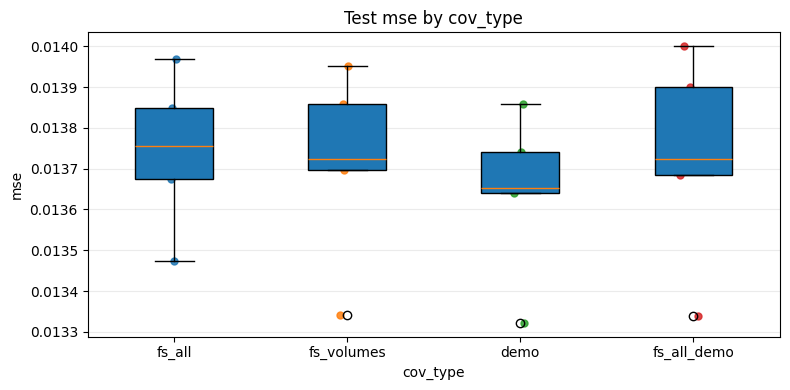

/tmp/ipykernel_3992207/3021143898.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, patch_artist=True)


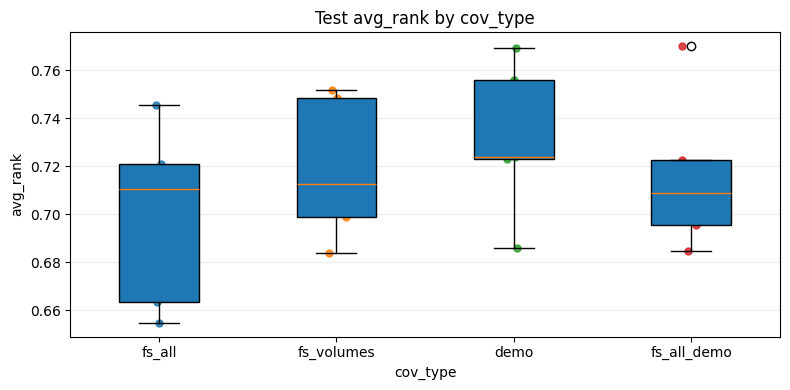

/tmp/ipykernel_3992207/3021143898.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, patch_artist=True)


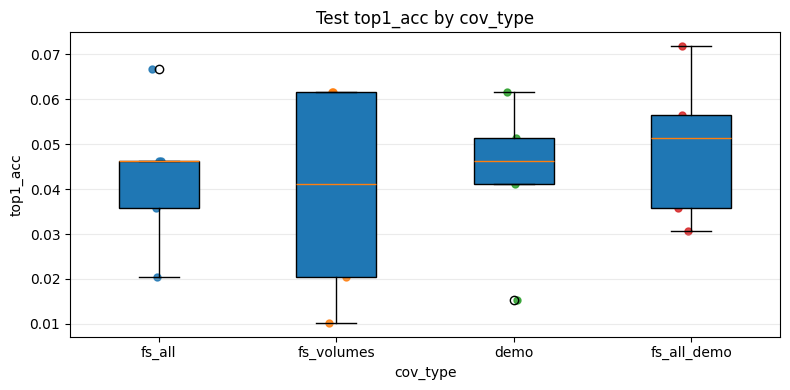

In [19]:
df = records_to_df(records)
complete_df = df[df["status"] == "complete"].copy()

if complete_df.empty:
    print("No complete records found.")
else:
    display(complete_df[["model", "source", "cov_type", "seed"] + [f"test_{m}" for m in METRICS_OF_INTEREST if f"test_{m}" in complete_df.columns]])

    for metric in METRICS_OF_INTEREST:
        col = f"test_{metric}"
        if col not in complete_df.columns:
            continue

        fig, ax = plt.subplots(figsize=(8, 4))
        data = [
            complete_df.loc[complete_df["cov_type"] == c, col].dropna().values
            for c in COV_TYPES
        ]
        labels = COV_TYPES
        ax.boxplot(data, labels=labels, patch_artist=True)

        rng = np.random.default_rng(7)
        for i, c in enumerate(COV_TYPES, start=1):
            vals = complete_df.loc[complete_df["cov_type"] == c, col].dropna().values
            if len(vals) == 0:
                continue
            x = i + rng.normal(0, 0.04, size=len(vals))
            ax.scatter(x, vals, s=25, alpha=0.85)

        ax.set_title(f"Test {metric} by cov_type")
        ax.set_xlabel("cov_type")
        ax.set_ylabel(metric)
        ax.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()


## 7. Optional Local Artifact Enrichment


In [16]:
records_enriched = enrich_records_with_local(records)
df_enriched = records_to_df(records_enriched)

print(f"Enriched complete rows: {(df_enriched['status'] == 'complete').sum()}")
print("Columns preview:")
print(df_enriched.columns[:40].tolist())


Enriched complete rows: 20
Columns preview:
['model', 'source', 'cov_type', 'seed', 'status', 'n_tune_trials', 'wandb_run_id', 'wandb_run_name', 'wandb_group', 'ray_tune_id', 'ray_trial_id', 'local_artifact', 'val_demeaned_r', 'val_mse', 'val_pearson_r', 'train_demeaned_r', 'train_mse', 'train_pearson_r', 'test_avg_rank', 'test_demeaned_pearson', 'test_mse', 'test_pearson', 'test_r2', 'test_top1_acc']
